[1.  0.5 0.  0.  0. ]
[1.  0.5 0.  0.  0. ]
[0.   0.75 1.   1.   1.  ]
[0.   0.75 1.   1.   1.  ]
[1.   0.25 0.   0.   0.  ]
[1.   0.25 0.   0.   0.  ]
[0.01002513 0.1026334  0.58578644 1.36754447 1.8       ]
[0.01002513 0.1026334  0.58578644 1.36754447 1.8       ]
[1.8        1.36754447 0.58578644 0.1026334  0.01002513]
[1.8        1.36754447 0.58578644 0.1026334  0.01002513]
(0.6666666666666667, 0.22222222222222243, 0.5656854249492306, -0.5999999999999694)
(0.6666666666666666, 0.2222222222222222, 0.565685424949238, -0.6000000000000001)
0.49999999999999983
0.5
25.0
shape > -1 does not hold
-20.0
[288.97991084 302.88261388 318.3157842  334.96403782 355.59134984
 376.3647503  396.33429147 399.68641924 405.92438748 430.91301529
 436.03878337 481.71652587 498.31081763 523.22141523 533.79157711
 475.24874133 590.1923455  753.77468347 684.11746391   0.        ]
[ 148.20245929  149.50922523  150.90286679  152.97907108  153.28701142
  156.21970094  163.13335622  190.26848165  217.33771501  22

/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_84953/278422786.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])


(3630, 19)

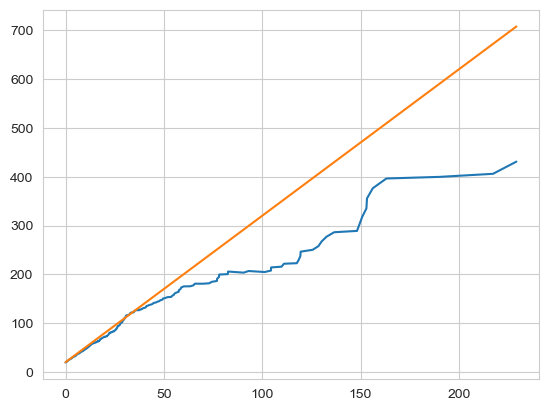

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

from matplotlib.pyplot import tight_layout
from statsmodels.sandbox.distributions.genpareto import meanexcess

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"

input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')
vars_all = ['psi_leaf_50_close', 'd_50_close', 'stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value',
        'leaf_hydraulic_capacitance', 'psi50_xylem', 'psi88_xylem', 'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0', 'jackson_root_beta',
        'pore_0', 'anet_max', 'root_area_index', 'wcont_sigma_deviation', 'g_bark']

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem',
              'g0', 'jackson_root_beta']
vars_all_ex = vars_all.copy()
vars_all_ex.append("RMSE_MAX")

df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))
df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)
#index_to_drop = df[(df['sid']==2)|(df['sid']==3)].index
#df.drop(index_to_drop, inplace=True)
df = df[df['RMSE_MAX'] < 1.1]
df_grp = df.groupby(['id'])[vars_all_ex].mean()
dv = df[vars_all]
dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
df_norm = (dv - dv.mean()) / dv.std()
df_norm['sid'] = df['sid']
df_norm.shape

In [2]:
vars_all

['psi_leaf_50_close',
 'd_50_close',
 'stem_hydraulic_capacitance',
 'k_xylem_sat',
 'huber_value',
 'leaf_hydraulic_capacitance',
 'psi50_xylem',
 'psi88_xylem',
 'g0',
 'g1',
 'k_soil_sat0',
 'psi_soil_sat0',
 'jackson_root_beta',
 'pore_0',
 'anet_max',
 'root_area_index',
 'wcont_sigma_deviation',
 'g_bark']

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [4]:
df_norm['alive'] = 1
df_norm.loc[df_norm['sid'] > 0, 'alive'] = 0
X_train, X_test, y_train, y_test = train_test_split(df_norm[vars_all], df_norm['alive'], test_size=0.3, random_state=42)
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=2909, class_weight='balanced')
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=2909)

In [5]:
df_norm[df_norm['alive'] == 1]['wcont_sigma_deviation'].mean()

1.6263447111246723

In [6]:
df_norm[df_norm['alive'] == 0]['wcont_sigma_deviation'].mean()

-0.40658617778116796

In [7]:
print(rf.score(X_train, y_train))
print(rf.score(X_test, y_test))

1.0
0.9981634527089073


In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
confusion_matrix(y_test, rf.predict(X_test))

array([[877,   1],
       [  1, 210]])

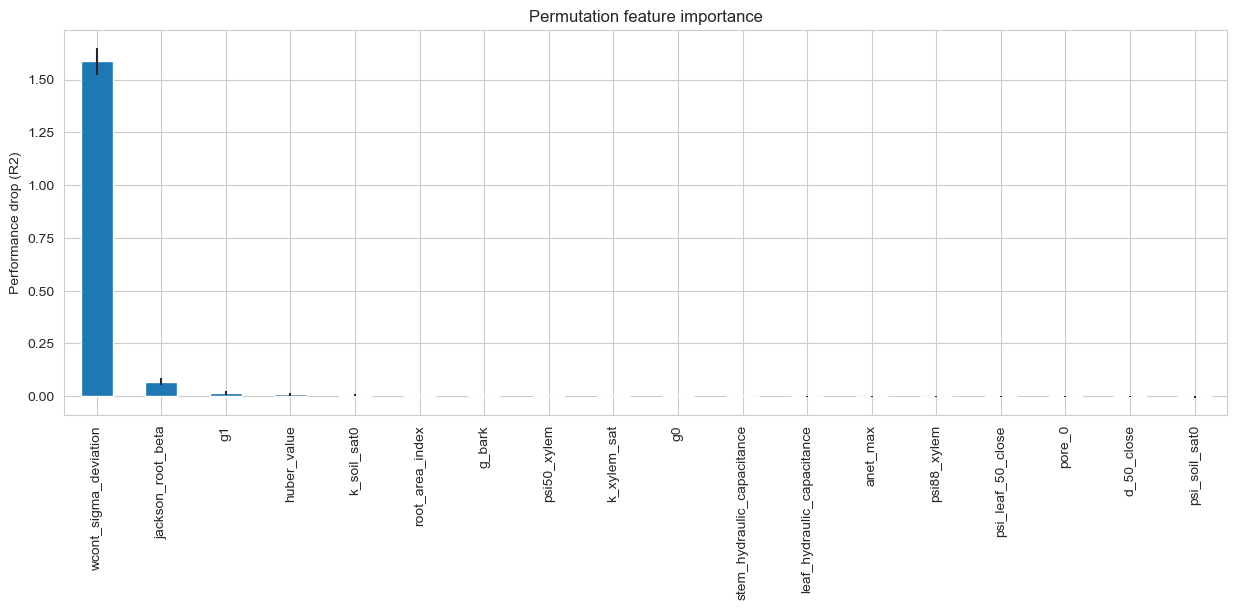

In [9]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_test,  # we use the test set
    y_test,
    scoring="r2",  # we can use any metric
    n_repeats=100,
    random_state=0,
)
importance = pd.DataFrame(
    {"importance_mean": perm["importances_mean"],
     "importance_std": perm["importances_std"]},
    index=rf.feature_names_in_)
importance["importance_mean"].sort_values(
    ascending=False
).plot(figsize=(15, 5), kind="bar", yerr=importance["importance_std"])
plt.title("Permutation feature importance")
plt.ylabel("Performance drop (R2)")
plt.show()

In [10]:
import shap
shap.initjs()

In [11]:
X_train

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,psi88_xylem,g0,g1,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,anet_max,root_area_index,wcont_sigma_deviation,g_bark
6168,0.773725,1.669071,-1.673131,-0.132967,0.110335,0.999153,1.247051,1.085522,-0.908717,-0.815655,-0.875443,-1.392483,-0.805656,-0.260622,0.479336,1.067898,-0.348429,-1.036302
9940,0.665772,1.396680,0.738783,-1.163490,-1.428107,0.158498,-1.503794,-0.920366,-1.203119,0.177398,-0.147667,-1.738808,2.421143,0.536521,-0.714084,-0.218225,1.546819,-0.619376
5602,0.662075,-1.243323,0.840630,1.517821,0.397872,-0.916313,-0.275490,-0.138749,0.577831,0.022646,1.503420,-1.297383,-0.308627,-1.257671,-0.549319,-0.468102,0.601837,0.929358
11640,-1.797183,0.359377,0.628171,0.088054,0.111536,-0.670819,1.441325,1.122963,2.194249,1.819912,-0.528174,-0.478498,-0.028256,0.003109,-0.931411,-1.133635,2.229998,1.947927
1613,0.319547,0.248403,0.230401,-1.120082,0.944697,1.819048,-1.106925,-1.583039,1.096317,1.239786,-0.267000,-0.277389,-0.904244,0.574747,-0.859810,0.441195,-0.601935,1.236497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,0.877282,-0.018477,-1.027162,-1.583486,-0.749023,-0.956160,1.236975,0.891861,-1.166579,-0.537581,0.658572,-0.313649,2.030465,1.013062,-1.461829,0.155725,1.471122,-1.035088
5207,0.395021,-2.083401,0.964275,-1.331594,1.776143,1.718793,0.730962,0.965438,1.473228,-0.421659,-0.744238,0.845167,-1.041043,-0.290120,-1.715442,0.500308,0.712811,1.759016
6128,0.478942,1.897299,0.480259,-0.584193,-0.910715,0.337894,1.459133,1.453709,-0.637875,0.406185,-0.233004,-0.588143,-0.799291,-0.382778,0.209234,0.252076,-0.638553,-0.754318
3102,-0.279411,0.942826,-0.053852,0.553526,-1.473084,-0.616142,-1.488601,-0.874034,-0.671437,-0.774527,-0.059277,-1.388699,-0.735509,-0.410864,-1.344883,-0.520505,0.522949,-0.461693


In [12]:
X_train.shape

(2541, 18)

In [13]:
explainer = shap.Explainer(rf)
shap_values = explainer(X_train)

In [14]:
shap_values[0,0,:]

.values =
array([-0.01143054,  0.01143054])

.base_values =
array([0.50040697, 0.49959303])

.data =
0.773725270386379

In [15]:
np.shape(shap_values.values)

(2541, 18, 2)

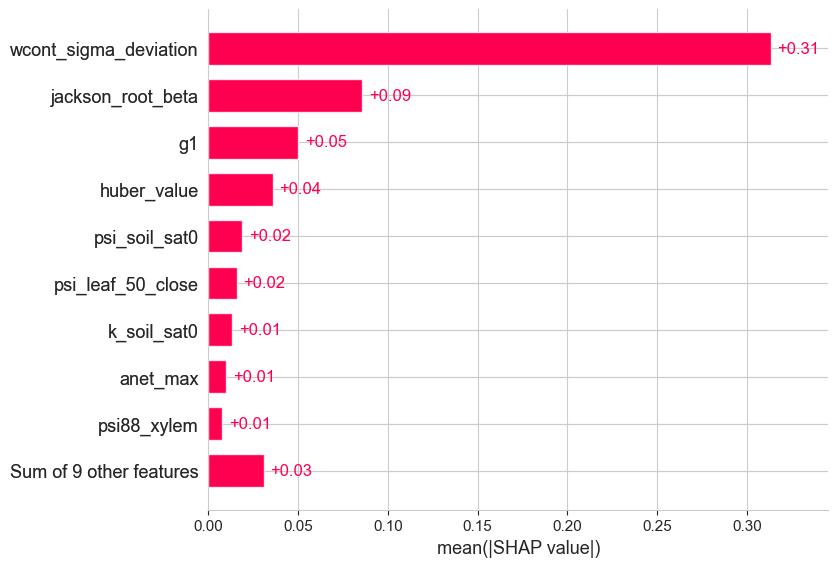

In [16]:
shap.plots.bar(shap_values[:,:,0])

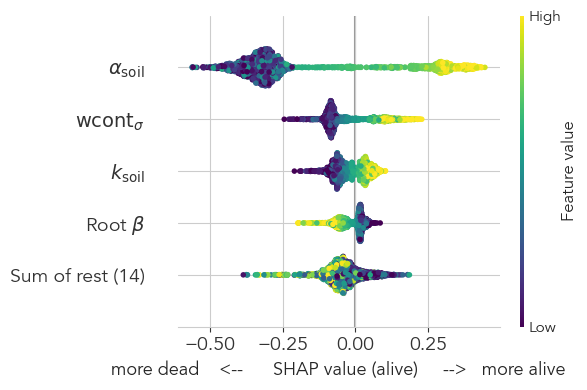

In [17]:

fig = plt.figure(figsize=(8, 6))
labs =list(reversed([r"$\alpha_\mathrm{soil}$",  r"$\mathrm{wcont}_\sigma$", r"$k_\mathrm{soil}$", r"Root $\beta$", "Sum of rest (14)"]))
# print(labs)
import matplotlib as mpl
plt.rcParams["font.family"] = "Avenir"
shap.plots.beeswarm(shap_values[:,:,1], color="viridis", max_display=5, show = False, plot_size=[6,4])
ax = plt.gca()
ax.set_xlabel("more dead    <--      SHAP value (alive)     -->   more alive")
ax.set_yticklabels(labs)
ax.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig(os.path.join(post_path, 'Fig2_shap_ALL.png'), dpi = 300)
plt.show()

In [19]:
vars_all

['psi_leaf_50_close',
 'd_50_close',
 'stem_hydraulic_capacitance',
 'k_xylem_sat',
 'huber_value',
 'leaf_hydraulic_capacitance',
 'psi50_xylem',
 'psi88_xylem',
 'g0',
 'g1',
 'k_soil_sat0',
 'psi_soil_sat0',
 'jackson_root_beta',
 'pore_0',
 'anet_max',
 'root_area_index',
 'wcont_sigma_deviation',
 'g_bark']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(df_grp[vars_all], df_grp['RMSE_MAX'], test_size=0.3, random_state=42)
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=2909)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, random_state=2909)

In [21]:
print(rf.score(X_train, y_train))
print(rf.score(X_test, y_test))

0.8992600113869715
0.3071564803165806


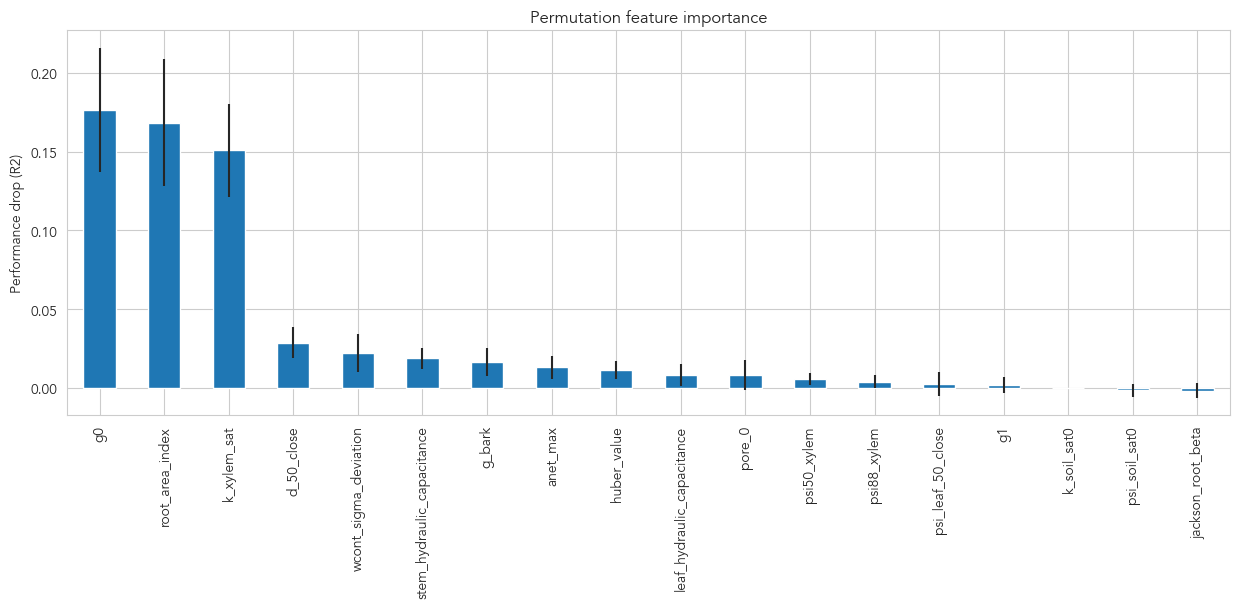

In [22]:
perm = permutation_importance(
    rf,
    X_test,  # we use the test set
    y_test,
    scoring="r2",  # we can use any metric
    n_repeats=100,
    random_state=0,
)
importance = pd.DataFrame(
    {"importance_mean": perm["importances_mean"],
     "importance_std": perm["importances_std"]},
    index=rf.feature_names_in_)
importance["importance_mean"].sort_values(
    ascending=False
).plot(figsize=(15, 5), kind="bar", yerr=importance["importance_std"])
plt.title("Permutation feature importance")
plt.ylabel("Performance drop (R2)")
plt.show()

In [23]:
explainer = shap.Explainer(rf)
shap_values = explainer(X_train)

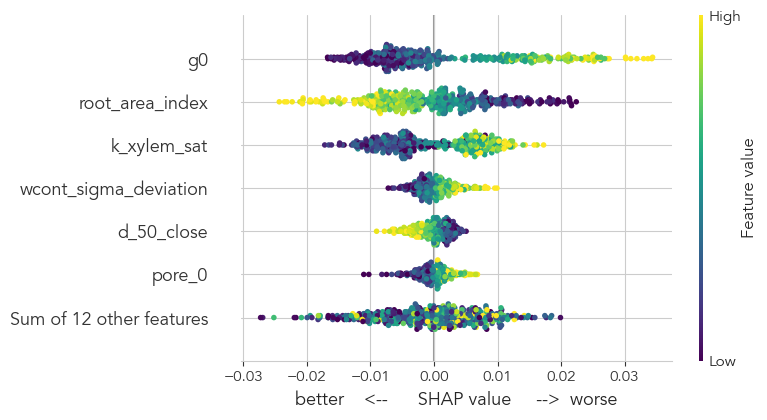

In [24]:
shap.plots.beeswarm(shap_values[:,:], color="viridis", max_display=7, show = False)
ax = plt.gca()
ax.set_xlabel("better    <--      SHAP value     -->  worse")
plt.tight_layout()
#plt.savefig(os.path.join("plt", 'shap_values.png'), dpi = 300)
plt.show()